In [1]:
import pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt, seaborn as sns

path = "./data/world-cup-2018.csv"
df = pd.read_csv(path)

df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [2]:
df["shot"] = (df["eventName"] == "Shot").astype(int)

In [3]:
df.loc[df["shot"] == 1, ["x2", "y2"]]

,x2,y2
117,100.0,100.0
154,0.0,0.0
197,0.0,0.0
232,0.0,0.0
372,100.0,100.0
...,...,...
101371,100.0,100.0
101457,100.0,100.0
101493,100.0,100.0
101620,0.0,0.0


In [4]:
x_max = 120
y_max = 75

df["x1"] = (df["x1"] / 100) * x_max
df["y1"] = (df["y1"] / 100) * y_max
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,shot
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,60.0,37.5,35.0,53.0,0


In [5]:
box_h = 44
box_w = 18

box_ymin = (y_max / 2) - (box_h / 2)
box_ymax = (y_max / 2) + (box_h / 2)
box_xmin = x_max - 18
box_xmax = x_max

df["g_event"] = (
    (df["y1"] > box_ymin) &
    (df["y1"] < box_ymax) &
    (df["x1"] > box_xmin) &
    (df["x1"] < box_xmax)
    ).astype(int)

df["g_event"].sum()

np.int64(3989)

In [6]:
g_df = df.groupby(["matchId", "teamId"]).agg(
    shots = ("shot", "sum"),
    g_events = ("g_event", "sum")
).reset_index()
g_df

,matchId,teamId,shots,g_events
0,"Argentina - Croatia, 0 - 3",Argentina,10,34
1,"Argentina - Croatia, 0 - 3",Croatia,13,25
2,"Argentina - Iceland, 1 - 1",Argentina,22,56
3,"Argentina - Iceland, 1 - 1",Iceland,8,25
4,"Australia - Peru, 0 - 2",Australia,11,48
...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,16
124,"Uruguay - Russia, 3 - 0",Russia,3,15
125,"Uruguay - Russia, 3 - 0",Uruguay,12,24
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,16


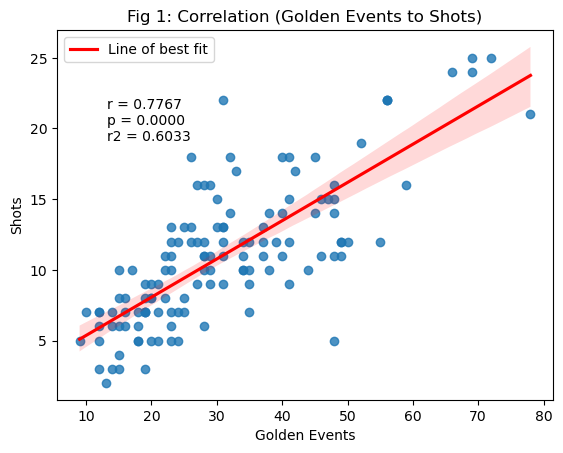

In [7]:
r, p = stats.pearsonr(g_df["g_events"], g_df["shots"])
r2 = r ** 2

text = f"""r = {r:.4f}
p = {p:.4f}
r2 = {r2:.4f}"""

reg = sns.regplot(
    data=g_df,
    x="g_events",
    y="shots",
    line_kws={
        "color": "red",
        "label": "Line of best fit"
        }
    )
reg.text(x=0.1, y=0.7, s=text, transform=reg.transAxes)
reg.set(
    title="Fig 1: Correlation (Golden Events to Shots)",
    xlabel="Golden Events",
    ylabel="Shots"
    )
plt.legend()
plt.show()